In [1]:
## IMPORTS 
import os
import sys 
LOCSCALE_2_SCRIPTS_PATH = "/home/abharadwaj1/papers/publications/2025_LocScale-2.0"
PLOT_DATA_STORE_PATH = "/home/abharadwaj1/papers/elife_paper/figure_information/archive_data/organized/data"
sys.path.append(LOCSCALE_2_SCRIPTS_PATH)
from scripts.utils.plot_utils import *

import numpy as np
import random
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm
import seaborn as sns
import pickle
import pandas as pd
from scripts.utils.plot_utils import pretty_plot_radial_profile, temporary_rcparams, configure_plot_scaling
from scripts.utils.general import setup_environment, create_folders_if_they_do_not_exist
from locscale.include.emmer.ndimage.map_utils import load_map, save_as_mrc
from locscale.include.emmer.ndimage.profile_tools import compute_radial_profile, estimate_bfactor_standard, frequency_array
random.seed(42)
np.random.seed(42)

In [2]:
parent_folder = os.path.join(PLOT_DATA_STORE_PATH, "rebuttal", "independant_quality_check", "emd_0282")

prediction_from_h2_dir = os.path.join(parent_folder, "predict_from_h2")

fem_from_h2_path = os.path.join(prediction_from_h2_dir, "emd_0282_fem_from_h2.mrc")
baseline_from_h2_path = os.path.join(prediction_from_h2_dir, "emd_0282_fem_from_h2_baseline.mrc")
h1_map_path = os.path.join(prediction_from_h2_dir, "emd_0282_half_map_1.map")
mask_path_h2 = os.path.join(prediction_from_h2_dir, "emd_0282_half_map_2_confidenceMap.mrc")


prediction_from_h1_dir = os.path.join(parent_folder, "predict_from_h1")
fem_from_h1_path = os.path.join(prediction_from_h1_dir, "emd_0282_fem_from_h1.mrc")
baseline_from_h1_path = os.path.join(prediction_from_h1_dir, "emd_0282_fem_from_h1_baseline.mrc")
h2_map_path = os.path.join(prediction_from_h1_dir, "emd_0282_half_map_2.map")
mask_path_h1 = os.path.join(prediction_from_h1_dir, "emd_0282_half_map_1_confidenceMap.mrc")

mask_path = os.path.join(parent_folder, "emd_0282_FDR_confidence_final.map")

In [3]:
def compute_masked_fsc_between_two_maps(map1_path, map2_path, mask_path):
    from locscale.include.emmer.ndimage.fsc_util import calculate_fsc_maps
    from locscale.include.emmer.ndimage.map_utils import load_map, save_as_mrc
    from locscale.include.emmer.ndimage.filter import get_cosine_mask
    from locscale.include.emmer.ndimage.profile_tools import frequency_array

    map1, apix = load_map(map1_path)
    map2, apix = load_map(map2_path)
    mask, _ = load_map(mask_path)

    mask_binarised = (mask > 0.5).astype(int)
    smooth_mask = get_cosine_mask(mask_binarised, 5)

    masked_map_1 = map1 * smooth_mask
    masked_map_2 = map2 * smooth_mask

    fsc_curve = calculate_fsc_maps(masked_map_1, masked_map_2)
    freq_array = frequency_array(fsc_curve, apix=apix)
    return freq_array, fsc_curve

In [4]:
freq, fsc_curve_between_fem_from_h2_and_h1 = compute_masked_fsc_between_two_maps(fem_from_h2_path, h1_map_path, mask_path_h2)

In [5]:
freq, fsc_curve_between_fem_from_h1_and_h2 = compute_masked_fsc_between_two_maps(fem_from_h1_path, h2_map_path, mask_path_h1)

In [6]:
_, fsc_curve_between_h1_and_h2 = compute_masked_fsc_between_two_maps(h1_map_path, h2_map_path, mask_path)

In [7]:
_, fsc_curve_between_baseline_from_h2_and_h1 = compute_masked_fsc_between_two_maps(baseline_from_h2_path, h1_map_path, mask_path_h2)

In [8]:
_, fsc_curve_between_baseline_from_h1_and_h2 = compute_masked_fsc_between_two_maps(baseline_from_h1_path, h2_map_path, mask_path_h1)

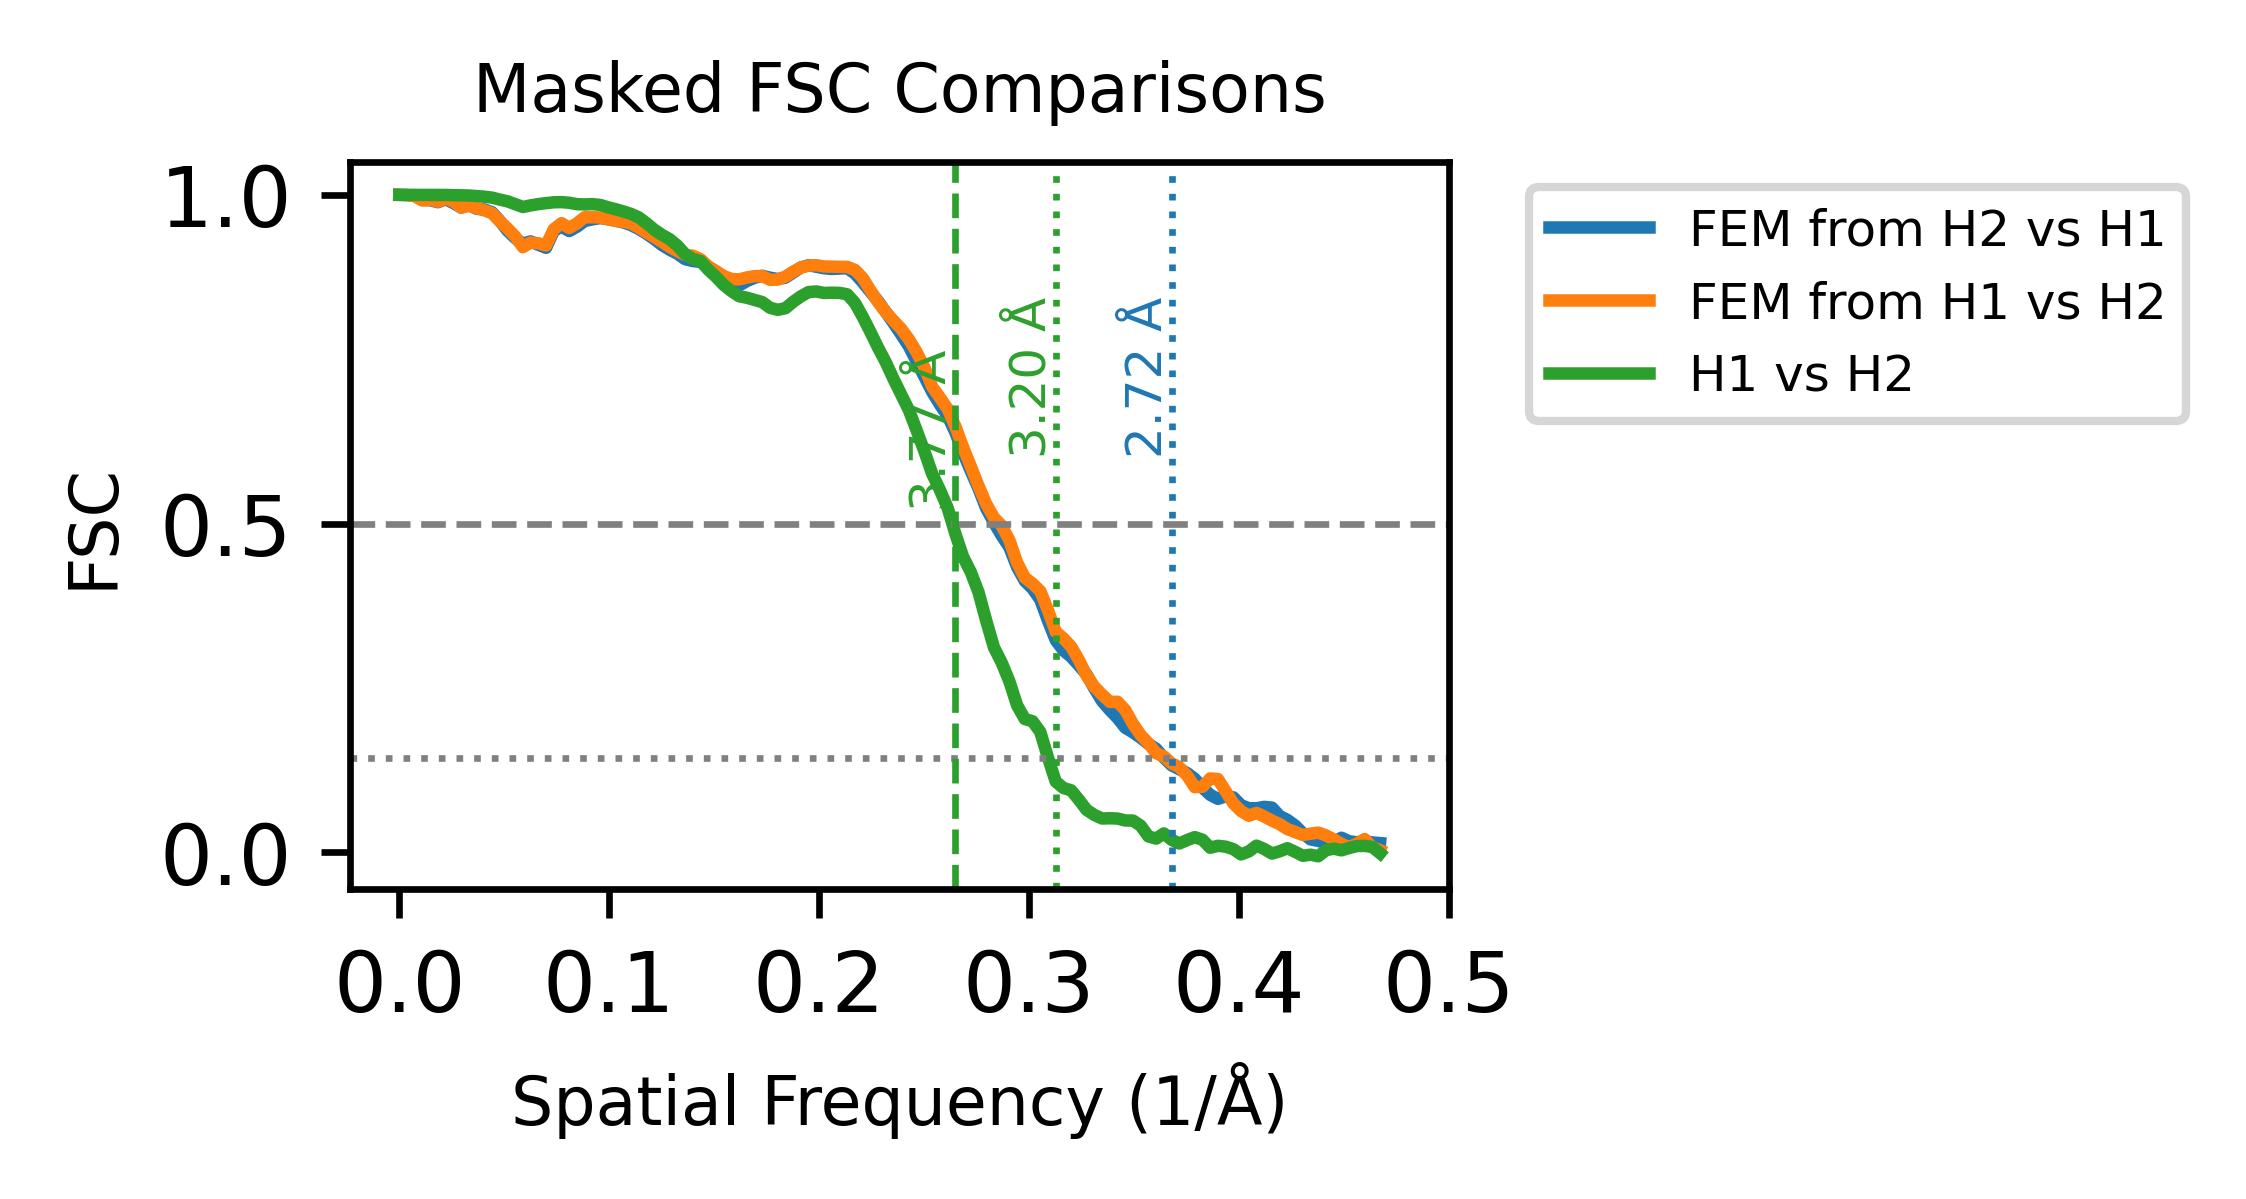

In [9]:
figsize_mm = (60, 40)

fig, ax = plt.subplots(figsize=(figsize_mm[0]/25.4, figsize_mm[1]/25.4), dpi=600)
sns.lineplot(x=freq, y=fsc_curve_between_fem_from_h2_and_h1, ax=ax, label="FEM from H2 vs H1", color="C0")
sns.lineplot(x=freq, y=fsc_curve_between_fem_from_h1_and_h2, ax=ax, label="FEM from H1 vs H2", color="C1")
sns.lineplot(x=freq, y=fsc_curve_between_h1_and_h2, ax=ax, label="H1 vs H2", color="C2")
# horizontal line at 0.5 
ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=0.8)
# horizontal line at 0.143
ax.axhline(y=0.143, color='gray', linestyle=':', linewidth=0.8)
# find the spatial frequency where fsc_curve_between_fem_from_h2_and_h1 crosses 0.143
crossing_index_h1_h2_143 = np.where(fsc_curve_between_h1_and_h2 < 0.143)[0]
crossing_index_fem_h2_h1_143 = np.where(fsc_curve_between_fem_from_h2_and_h1 < 0.143)[0]
crossing_index_fem_h1_h2_143 = np.where(fsc_curve_between_fem_from_h1_and_h2 < 0.143)[0]
crossing_index_h1_h2_50 = np.where(fsc_curve_between_h1_and_h2 < 0.5)[0]
crossing_index_fem_h2_h1_50 = np.where(fsc_curve_between_fem_from_h2_and_h1 < 0.5)[0]
crossing_index_fem_h1_h2_50 = np.where(fsc_curve_between_fem_from_h1_and_h2 < 0.5)[0]

if len(crossing_index_h1_h2_143) > 0:
    res_h1_h2_143 = 1 / freq[crossing_index_h1_h2_143[0]]
    ax.axvline(x=freq[crossing_index_h1_h2_143[0]], color='C2', linestyle=':', linewidth=0.8)
    ax.text(freq[crossing_index_h1_h2_143[0]], 0.6, f"{res_h1_h2_143:.2f} Å", color='C2', fontsize=6, rotation=90, va='bottom', ha='right')

if len(crossing_index_fem_h2_h1_143) > 0:
    res_fem_h2_h1_143 = 1 / freq[crossing_index_fem_h2_h1_143[0]]
    ax.axvline(x=freq[crossing_index_fem_h2_h1_143[0]], color='C0', linestyle=':', linewidth=0.8)
    ax.text(freq[crossing_index_fem_h2_h1_143[0]], 0.6, f"{res_fem_h2_h1_143:.2f} Å", color='C0', fontsize=6, rotation=90, va='bottom', ha='right')

if len(crossing_index_h1_h2_50) > 0:
    res_h1_h2_50 = 1 / freq[crossing_index_h1_h2_50[0]]
    ax.axvline(x=freq[crossing_index_h1_h2_50[0]], color='C2', linestyle='--', linewidth=0.8)
    ax.text(freq[crossing_index_h1_h2_50[0]], 0.52, f"{res_h1_h2_50:.2f} Å", color='C2', fontsize=6, rotation=90, va='bottom', ha='right')
    
ax.set_xlabel("Spatial Frequency (1/Å)", fontsize=8)
ax.set_ylabel("FSC", fontsize=8)
ax.set_title("Masked FSC Comparisons", fontsize=8)
ax.set_xticks(np.arange(0, 0.6, 0.1))
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=6)
figsave_path = os.path.join(parent_folder, "global_fsc_comparisons.pdf")
fig.savefig(figsave_path, bbox_inches='tight')

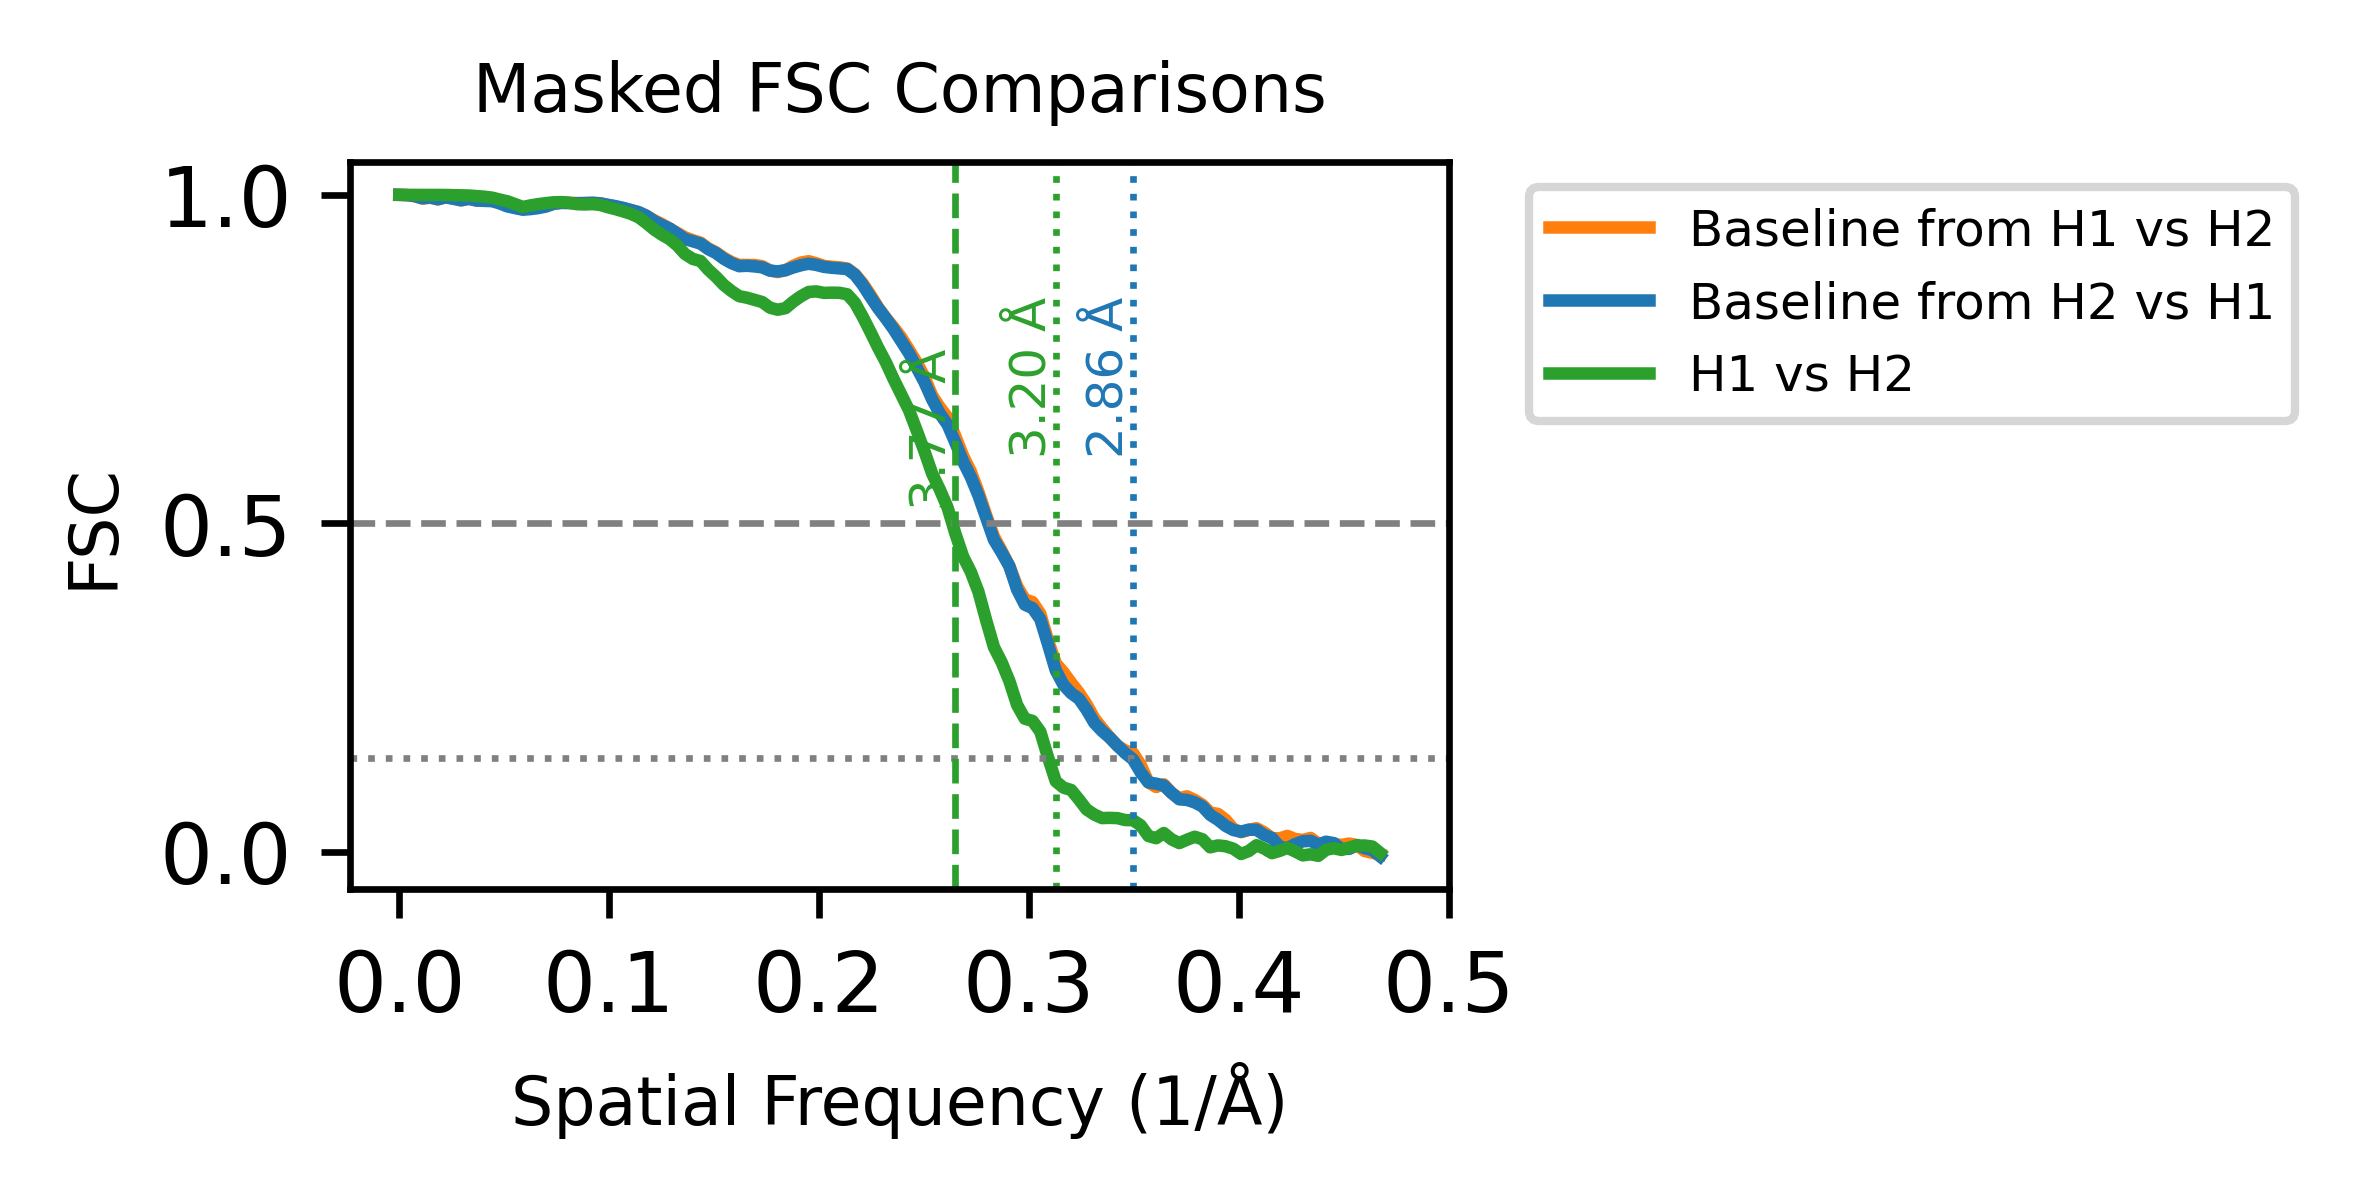

In [10]:
figsize_mm = (60, 40)

fig, ax = plt.subplots(figsize=(figsize_mm[0]/25.4, figsize_mm[1]/25.4), dpi=600)
sns.lineplot(x=freq, y=fsc_curve_between_baseline_from_h1_and_h2, ax=ax, label="Baseline from H1 vs H2", color="C1")
sns.lineplot(x=freq, y=fsc_curve_between_baseline_from_h2_and_h1, ax=ax, label="Baseline from H2 vs H1", color="C0")
sns.lineplot(x=freq, y=fsc_curve_between_h1_and_h2, ax=ax, label="H1 vs H2", color="C2")
# horizontal line at 0.5 
ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=0.8)
# horizontal line at 0.143
ax.axhline(y=0.143, color='gray', linestyle=':', linewidth=0.8)
# find the spatial frequency where fsc_curve_between_fem_from_h2_and_h1 crosses 0.143
crossing_index_h1_h2_143 = np.where(fsc_curve_between_h1_and_h2 < 0.143)[0]
crossing_index_fem_h2_h1_143 = np.where(fsc_curve_between_baseline_from_h2_and_h1 < 0.143)[0]
crossing_index_fem_h1_h2_143 = np.where(fsc_curve_between_baseline_from_h1_and_h2 < 0.143)[0]
crossing_index_h1_h2_50 = np.where(fsc_curve_between_h1_and_h2 < 0.5)[0]
crossing_index_fem_h2_h1_50 = np.where(fsc_curve_between_baseline_from_h2_and_h1 < 0.5)[0]
crossing_index_fem_h1_h2_50 = np.where(fsc_curve_between_baseline_from_h1_and_h2 < 0.5)[0]

if len(crossing_index_h1_h2_143) > 0:
    res_h1_h2_143 = 1 / freq[crossing_index_h1_h2_143[0]]
    ax.axvline(x=freq[crossing_index_h1_h2_143[0]], color='C2', linestyle=':', linewidth=0.8)
    ax.text(freq[crossing_index_h1_h2_143[0]], 0.6, f"{res_h1_h2_143:.2f} Å", color='C2', fontsize=6, rotation=90, va='bottom', ha='right')

if len(crossing_index_fem_h2_h1_143) > 0:
    res_fem_h2_h1_143 = 1 / freq[crossing_index_fem_h2_h1_143[0]]
    ax.axvline(x=freq[crossing_index_fem_h2_h1_143[0]], color='C0', linestyle=':', linewidth=0.8)
    ax.text(freq[crossing_index_fem_h2_h1_143[0]], 0.6, f"{res_fem_h2_h1_143:.2f} Å", color='C0', fontsize=6, rotation=90, va='bottom', ha='right')

if len(crossing_index_h1_h2_50) > 0:
    res_h1_h2_50 = 1 / freq[crossing_index_h1_h2_50[0]]
    ax.axvline(x=freq[crossing_index_h1_h2_50[0]], color='C2', linestyle='--', linewidth=0.8)
    ax.text(freq[crossing_index_h1_h2_50[0]], 0.52, f"{res_h1_h2_50:.2f} Å", color='C2', fontsize=6, rotation=90, va='bottom', ha='right')
    
ax.set_xlabel("Spatial Frequency (1/Å)", fontsize=8)
ax.set_ylabel("FSC", fontsize=8)
ax.set_title("Masked FSC Comparisons", fontsize=8)
ax.set_xticks(np.arange(0, 0.6, 0.1))
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=6)
figsave_path = os.path.join(parent_folder, "global_fsc_comparisons_baselines.pdf")
fig.savefig(figsave_path, bbox_inches='tight')

In [11]:
# save masked maps for local fsc comparison
from locscale.include.emmer.ndimage.filter import get_cosine_mask
local_fsc_dir = os.path.join(parent_folder, "local_fsc_comparisons")

masked_fem_from_h1_map_path = os.path.join(local_fsc_dir, "emd_0282_fem_from_h1_masked.mrc")
masked_fem_from_h2_map_path = os.path.join(local_fsc_dir, "emd_0282_fem_from_h2_masked.mrc")
masked_h1_map_path = os.path.join(local_fsc_dir, "emd_0282_half_map_1_masked.mrc")
masked_h2_map_path = os.path.join(local_fsc_dir, "emd_0282_half_map_2_masked.mrc")

fem_from_h1_map, apix = load_map(fem_from_h1_path)
h1_map, _ = load_map(h1_map_path)
fem_from_h2_map, _ = load_map(fem_from_h2_path)
h2_map, _ = load_map(h2_map_path)
mask, _ = load_map(mask_path)

mask_binarised = (mask > 0.5).astype(int)
smooth_mask = get_cosine_mask(mask_binarised, 5)

masked_fem_from_h1_map = fem_from_h1_map * smooth_mask
masked_h1_map = h1_map * smooth_mask
masked_fem_from_h2_map = fem_from_h2_map * smooth_mask
masked_h2_map = h2_map * smooth_mask

save_as_mrc(masked_fem_from_h1_map, masked_fem_from_h1_map_path, apix)
save_as_mrc(masked_h1_map, masked_h1_map_path, apix)
save_as_mrc(masked_fem_from_h2_map, masked_fem_from_h2_map_path, apix)
save_as_mrc(masked_h2_map, masked_h2_map_path, apix)



In [14]:
localresolutions_fem_from_h1_v_h2_path = os.path.join(local_fsc_dir, "emd_0282_fem_from_h1_masked_localResolutions.mrc")
localresolutions_fem_from_h2_v_h1_path = os.path.join(local_fsc_dir, "emd_0282_fem_from_h2_masked_localResolutions.mrc")
localresolutions_h1_v_h2_path = os.path.join(local_fsc_dir, "emd_0282_half_map_1_masked_localResolutions.mrc")

pvddt_fem_from_h1_path = os.path.join(local_fsc_dir, "emd_0282_fem_from_h1_pVDDT.mrc")
pvddt_fem_from_h2_path = os.path.join(local_fsc_dir, "emd_0282_fem_from_h2_pVDDT.mrc")

localresolutions_fem_from_h1_v_h2, apix = load_map(localresolutions_fem_from_h1_v_h2_path)
localresolutions_fem_from_h2_v_h1, _ = load_map(localresolutions_fem_from_h2_v_h1_path)
localresolutions_h1_v_h2, _ = load_map(localresolutions_h1_v_h2_path)

pvddt_fem_from_h1, _ = load_map(pvddt_fem_from_h1_path)
pvddt_fem_from_h2, _ = load_map(pvddt_fem_from_h2_path)

delta_localresolution_fem_from_h1 = localresolutions_fem_from_h1_v_h2 - localresolutions_h1_v_h2
delta_localresolution_fem_from_h2 = localresolutions_fem_from_h2_v_h1 - localresolutions_h1_v_h2

absolute_pvddt_fem_from_h1 = np.abs(pvddt_fem_from_h1)
absolute_pvddt_fem_from_h2 = np.abs(pvddt_fem_from_h2)

# save delta local resolution maps and absolute pVDDT maps

delta_localresolution_fem_from_h1_path = os.path.join(local_fsc_dir, "emd_0282_fem_from_h1_delta_localResolutions.mrc")
delta_localresolution_fem_from_h2_path = os.path.join(local_fsc_dir, "emd_0282_fem_from_h2_delta_localResolutions.mrc")
absolute_pvddt_fem_from_h1_path = os.path.join(local_fsc_dir, "emd_0282_fem_from_h1_absolute_pVDDT.mrc")
absolute_pvddt_fem_from_h2_path = os.path.join(local_fsc_dir, "emd_0282_fem_from_h2_absolute_pVDDT.mrc")
save_as_mrc(delta_localresolution_fem_from_h1, delta_localresolution_fem_from_h1_path, apix)
save_as_mrc(delta_localresolution_fem_from_h2, delta_localresolution_fem_from_h2_path, apix)
save_as_mrc(absolute_pvddt_fem_from_h1, absolute_pvddt_fem_from_h1_path, apix)
save_as_mrc(absolute_pvddt_fem_from_h2, absolute_pvddt_fem_from_h2_path, apix)



In [36]:
from locscale.include.emmer.ndimage.map_tools import get_atomic_model_mask

pdb_path = "/home/abharadwaj1/papers/elife_paper/figure_information/archive_data/organized/data/rebuttal/independant_quality_check/emd_0282/pdb_6huo.pdb"
model_mask_path = get_atomic_model_mask(emmap_path=fem_from_h1_path, pdb_path=pdb_path)

In [39]:
model_mask, _ = load_map(model_mask_path)


In [50]:
# compare local resolution improvement when using half map 1 for prediction 
threshold_to_view = 0.18
masked_fem_map = (masked_fem_from_h1_map > threshold_to_view).astype(int)
masked_model_mask = (model_mask > 0.5).astype(int)
mask_to_use = masked_fem_map * masked_model_mask
all_voxels_in_mask = list(zip(*np.where(mask_to_use)))
print(all_voxels_in_mask[:2])
sampled_voxels = random.sample(all_voxels_in_mask, 10000)

improvement_in_local_resolution_fem_from_h1_list = []
absolute_pvddt_values_fem_from_h1_list = []
pvddt_values_fem_from_h1_list = []
for voxel in sampled_voxels:
    assert masked_fem_from_h1_map[voxel[0], voxel[1], voxel[2]] > threshold_to_view, "Sampled voxel is not in the mask!"
    delta_local_resolution_h1 = delta_localresolution_fem_from_h1[voxel[0], voxel[1], voxel[2]]
    absolute_pvddt_value_h1 = absolute_pvddt_fem_from_h1[voxel[0], voxel[1], voxel[2]]
    pvddt_value_h1 = pvddt_fem_from_h1[voxel[0], voxel[1], voxel[2]]
    improvement_in_local_resolution_fem_from_h1_list.append(delta_local_resolution_h1)
    absolute_pvddt_values_fem_from_h1_list.append(absolute_pvddt_value_h1)
    pvddt_values_fem_from_h1_list.append(pvddt_value_h1)
    


[(73, 115, 126), (74, 115, 126)]


Text(0, 0.5, 'Improvement in Local Resolution (FEM from H1 vs H1)')

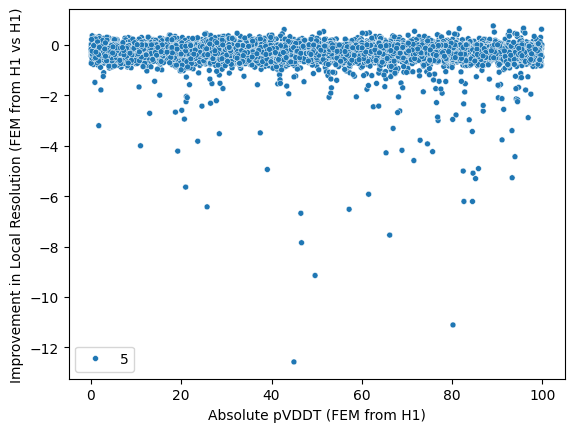

In [53]:
sns.scatterplot(x=absolute_pvddt_values_fem_from_h1_list, y=improvement_in_local_resolution_fem_from_h1_list, size=5)
plt.xlabel("Absolute pVDDT (FEM from H1)")
plt.ylabel("Improvement in Local Resolution (FEM from H1 vs H1)")

Text(0, 0.5, 'Improvement in Local Resolution (FEM from H1 vs H1)')

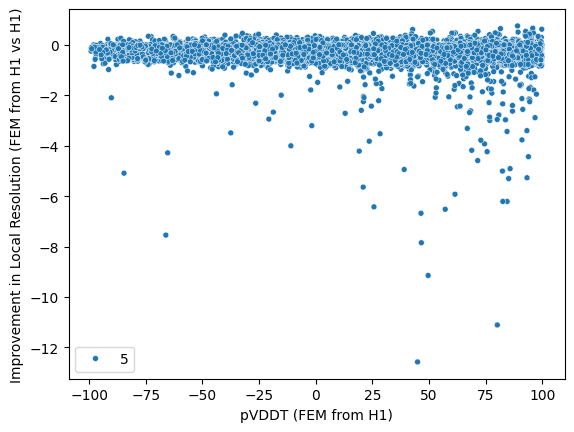

In [54]:
sns.scatterplot(x=pvddt_values_fem_from_h1_list, y=improvement_in_local_resolution_fem_from_h1_list, size=5)
plt.xlabel("pVDDT (FEM from H1)")
plt.ylabel("Improvement in Local Resolution (FEM from H1 vs H1)")
